# Load ESWD

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
clean_events=pd.read_csv("ESWD_events_matrix_date_province.csv")
clean_events

,DATE,TYPE_EVENT,PROVINCE,LATITUDE,LONGITUDE,HAZARD_GROUP
0,2022-12-16,WIND,PD,45.415,11.882,WIND
1,2022-11-22,WIND,VE,45.533,12.645,WIND
2,2022-11-22,WIND,VR,45.640,11.001,WIND
3,2022-11-22,WIND,TV,45.644,12.251,WIND
4,2022-11-22,WIND,TV,45.603,12.237,WIND
...,...,...,...,...,...,...
800,2002-06-06,TORNADO,VE,45.439,12.350,WIND
801,2001-10-21,TORNADO,VI,45.475,11.698,WIND
802,2001-07-07,TORNADO,PD,45.433,11.917,WIND
803,2001-07-07,TORNADO,VE,45.507,12.030,WIND


In [3]:
def _to_month_start(x):
    return pd.to_datetime(x, errors="coerce")

def add_province_to_model_points(
    model_csv: str,
    province_shp: str,
    province_col_shp: str,           # field in shapefile (e.g. "SIGLA" or "COD_PROV")
    lon_col: str = "lon",
    lat_col: str = "lat",
    date_col: str = "time",          # or "date"
    points_crs: str = "EPSG:4326",   # adjust if your model lon/lat are UTM
    year_range=(2018, 2022),
):
    """Load model event pixels, filter years, spatial join to provinces, return points with 'province' + 'date'."""
    df = pd.read_csv(model_csv)

    # parse date
    if date_col not in df.columns:
        raise ValueError(f"Missing '{date_col}' in {model_csv}. Found: {df.columns.tolist()}")
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[lon_col, lat_col, date_col])

    y0, y1 = year_range
    df = df[(df[date_col].dt.year >= y0) & (df[date_col].dt.year <= y1)].copy()

    prov = gpd.read_file(province_shp)
    if prov.crs is None:
        raise ValueError("Province shapefile CRS is missing.")
    if province_col_shp not in prov.columns:
        raise ValueError(f"'{province_col_shp}' not in shapefile columns: {prov.columns.tolist()}")

    gpts = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=points_crs
    )
    if gpts.crs != prov.crs:
        gpts = gpts.to_crs(prov.crs)

    joined = gpd.sjoin(
        gpts,
        prov[[province_col_shp, "geometry"]],
        how="inner",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")

    joined = pd.DataFrame(joined.drop(columns="geometry"))
    joined = joined.rename(columns={province_col_shp: "province"})
    joined["province"] = joined["province"].astype(str).str.strip()

    # normalize date to day
    joined["date"] = joined[date_col].dt.floor("D")
    return joined


def model_daily_presence_by_province(model_points_with_prov: pd.DataFrame):
    """Return province-day presence (model=1 if any event pixel that day in province)."""
    daily = (
        model_points_with_prov.groupby(["province", "date"])
        .size()
        .reset_index(name="n_pixels")
    )
    daily["model"] = 1
    return daily[["province", "date", "model", "n_pixels"]]


def eswd_daily_presence(
    eswd_df: pd.DataFrame,
    hazard_col: str,             # "PRECIP" or "WIND"
    date_col: str = "DATE",
    province_col: str = "PROVINCE",
    year_range=(2018, 2022),
):
    """Return ESWD province-day presence (obs=1 if ESWD hazard occurs that day in province)."""
    obs = eswd_df.copy()
    obs[date_col] = pd.to_datetime(obs[date_col], errors="coerce")
    obs = obs.dropna(subset=[date_col, province_col])

    y0, y1 = year_range
    obs = obs[(obs[date_col].dt.year >= y0) & (obs[date_col].dt.year <= y1)].copy()

    obs["province"] = obs[province_col].astype(str).str.strip()
    obs["date"] = obs[date_col].dt.floor("D")

    # keep only hazard events
    if hazard_col not in obs.columns:
        raise ValueError(f"'{hazard_col}' not in ESWD df columns: {obs.columns.tolist()}")

    obs = obs[pd.to_numeric(obs[hazard_col], errors="coerce").fillna(0) == 1].copy()
    obs_daily = obs.groupby(["province", "date"]).size().reset_index(name="n_events")
    obs_daily["obs"] = 1
    return obs_daily[["province", "date", "obs", "n_events"]]


def apply_time_window_to_obs(obs_daily: pd.DataFrame, window_days: int):
    """
    Expand ESWD positives to ±window_days within each province.
    Returns df with columns province, date, obs_window=1.
    """
    if window_days < 0:
        raise ValueError("window_days must be >= 0")

    rows = []
    for prov, sub in obs_daily.groupby("province"):
        dates = pd.to_datetime(sub["date"]).unique()
        expanded = set()
        for d in dates:
            for k in range(-window_days, window_days + 1):
                expanded.add(pd.Timestamp(d) + pd.Timedelta(days=k))
        rows.extend([(prov, dt) for dt in expanded])

    out = pd.DataFrame(rows, columns=["province", "date"])
    out["obs_window"] = 1
    return out.drop_duplicates()


def build_province_day_grid(provinces, start_date, end_date):
    """All province-day combinations (for proper TN counting)."""
    all_dates = pd.date_range(start_date, end_date, freq="D")
    grid = pd.MultiIndex.from_product([provinces, all_dates], names=["province", "date"]).to_frame(index=False)
    return grid


def evaluate_and_plot_confusion(
    model_daily: pd.DataFrame,
    obs_daily: pd.DataFrame,
    year_range=(2018, 2022),
    window_days: int = 1,
    title: str = "Confusion matrix",
):
    """
    Confusion on province-day, allowing ±window_days tolerance by dilating OBS to obs_window.
    NOTE: This function is not used in the validation code, becauce the eswd reports impacts, while the model is focussed on extreme events, 
    which often do not cause any impact at all.
    """
    # build obs window
    obs_win = apply_time_window_to_obs(obs_daily, window_days=window_days)

    # time bounds
    y0, y1 = year_range
    start_date = pd.Timestamp(f"{y0}-01-01")
    end_date = pd.Timestamp(f"{y1}-12-31")

    # union of provinces seen in either dataset
    provinces = sorted(set(model_daily["province"]) | set(obs_daily["province"]))
    grid = build_province_day_grid(provinces, start_date, end_date)

    # merge model
    merged = grid.merge(model_daily[["province", "date", "model"]], on=["province", "date"], how="left")
    merged["model"] = merged["model"].fillna(0).astype(int)

    # merge obs window
    merged = merged.merge(obs_win, on=["province", "date"], how="left")
    merged["obs"] = merged["obs_window"].fillna(0).astype(int)
    merged = merged.drop(columns=["obs_window"])

    # confusion parts
    obs = merged["obs"].values
    mod = merged["model"].values
    TP = int(((obs == 1) & (mod == 1)).sum())
    TN = int(((obs == 0) & (mod == 0)).sum())
    FP = int(((obs == 0) & (mod == 1)).sum())
    FN = int(((obs == 1) & (mod == 0)).sum())

    precision = TP / (TP + FP) if (TP + FP) else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else np.nan
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else np.nan

    metrics = dict(TP=TP, TN=TN, FP=FP, FN=FN,
                   precision=precision, recall=recall, f1=f1, accuracy=accuracy)

    # plot confusion matrix (matplotlib only; no seaborn dependency)
    cm = np.array([[TP, FN],
                   [FP, TN]])

    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    im = ax.imshow(cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Model: Event", "Model: No"])
    ax.set_yticklabels(["Obs±w: Event", "Obs±w: No"])
    ax.set_title(f"{title}\n(window = ±{window_days} day)")

    # annotate
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{int(v)}", ha="center", va="center", fontsize=12)

    plt.tight_layout()
    plt.show()

    return merged, metrics

import pandas as pd
from datetime import timedelta

def validate_eswd_event_matching(
    eswd_df: pd.DataFrame,
    model_daily_df: pd.DataFrame,
    hazard_group: str,                # "WIND" or "PRECIP"
    window_days: int = 1,
    year_range=(2018, 2022),
):
    """
    For each ESWD event, check if model has an extreme
    in same province within ±window_days (hit rate).

    Returns:
        detailed_df (with match flag),
        summary_metrics dict
    """

    # --- Clean ESWD
    eswd = eswd_df.copy()
    eswd["DATE"] = pd.to_datetime(eswd["DATE"], errors="coerce")
    eswd = eswd.dropna(subset=["DATE"])

    y0, y1 = year_range
    eswd = eswd[(eswd["DATE"].dt.year >= y0) & (eswd["DATE"].dt.year <= y1)]

    eswd = eswd[
        eswd["HAZARD_GROUP"].str.upper() == hazard_group.upper()
    ].copy()

    eswd["province"] = eswd["PROVINCE"].astype(str).str.strip()
    eswd["date"] = eswd["DATE"].dt.floor("D")

    # --- Clean model daily presence
    model = model_daily_df.copy()
    model["date"] = pd.to_datetime(model["date"])
    model["province"] = model["province"].astype(str).str.strip()

    matches = []

    for _, row in eswd.iterrows():
        prov = row["province"]
        date = row["date"]

        start = date - timedelta(days=window_days)
        end   = date + timedelta(days=window_days)

        sub = model[
            (model["province"] == prov) &
            (model["date"] >= start) &
            (model["date"] <= end)
        ]

        matched = len(sub) > 0

        matches.append({
            "province": prov,
            "event_date": date,
            "matched": int(matched)
        })

    detailed_df = pd.DataFrame(matches)

    total_events = len(detailed_df)
    hits = detailed_df["matched"].sum()
    misses = total_events - hits

    metrics = {
        "total_events": total_events,
        "hits": int(hits),
        "misses": int(misses),
        "hit_rate": hits / total_events if total_events else 0
    }

    return detailed_df, metrics

In [4]:
# --- Inputs ---
ESWD_CSV = "ESWD_events_matrix_date_province.csv"      # or already loaded df
PRECIP_MODEL_CSV = "OUTPUT/CMCC_REA/prec/99_YES_F_clust_clean_veneto_only.csv"
WIND_MODEL_CSV   = "OUTPUT/CMCC_REA/wind/99_YES_F_clust_clean_veneto_only.csv"

PROVINCE_SHP = "Limiti/Regioni/c0104021_province.shp"
PROVINCE_COL = "provincia"   # <-- set this to the real field in the shapefile (code like BL, VR...)

YEAR_RANGE = (2018, 2022)
WINDOW_DAYS = 1  # tunable

# Load ESWD matrix
eswd = pd.read_csv(ESWD_CSV)

# --- PRECIP ---
#prec_obs_daily = eswd_daily_presence_from_long(eswd, hazard_group="PRECIP", year_range=YEAR_RANGE)

In [10]:
eswd

,DATE,TYPE_EVENT,PROVINCE,LATITUDE,LONGITUDE,HAZARD_GROUP
0,2022-12-16,WIND,PD,45.415,11.882,WIND
1,2022-11-22,WIND,VE,45.533,12.645,WIND
2,2022-11-22,WIND,VR,45.640,11.001,WIND
3,2022-11-22,WIND,TV,45.644,12.251,WIND
4,2022-11-22,WIND,TV,45.603,12.237,WIND
...,...,...,...,...,...,...
800,2002-06-06,TORNADO,VE,45.439,12.350,WIND
801,2001-10-21,TORNADO,VI,45.475,11.698,WIND
802,2001-07-07,TORNADO,PD,45.433,11.917,WIND
803,2001-07-07,TORNADO,VE,45.507,12.030,WIND


In [5]:
#prec_obs_daily

In [6]:
prec_pts = add_province_to_model_points(
    model_csv=PRECIP_MODEL_CSV,
    province_shp=PROVINCE_SHP,
    province_col_shp=PROVINCE_COL,
    date_col="date",          # or "time"
    points_crs="EPSG:4326",
    year_range=YEAR_RANGE
)
prec_model_daily = model_daily_presence_by_province(prec_pts)

detailed_prec, metrics_prec = validate_eswd_event_matching(
    eswd_df=eswd,
    model_daily_df=prec_model_daily,
    hazard_group="PRECIP",
    window_days=1,
    year_range=(2018, 2022)
)

print(metrics_prec)

{'total_events': 157, 'hits': 95, 'misses': 62, 'hit_rate': 0.6050955414012739}


In [7]:
detailed_prec

,province,event_date,matched
0,VE,2022-11-04,0
1,VI,2022-09-29,1
2,VE,2022-09-11,0
3,VE,2022-09-11,0
4,VE,2022-09-11,0
...,...,...,...
152,VR,2018-05-12,1
153,BL,2018-01-09,1
154,BL,2018-01-09,1
155,BL,2018-01-09,1


In [8]:
wind_pts = add_province_to_model_points(
    model_csv=WIND_MODEL_CSV,
    province_shp=PROVINCE_SHP,
    province_col_shp=PROVINCE_COL,
    date_col="date",          # or "time"
    points_crs="EPSG:4326",
    year_range=YEAR_RANGE
)
wind_model_daily = model_daily_presence_by_province(wind_pts)

detailed_wind, metrics_wind = validate_eswd_event_matching(
    eswd_df=eswd,
    model_daily_df=wind_model_daily,
    hazard_group="WIND",
    window_days=1,
    year_range=(2018, 2022)
)

print(metrics_wind)

{'total_events': 157, 'hits': 95, 'misses': 62, 'hit_rate': 0.6050955414012739}


In [9]:
detailed_wind

,province,event_date,matched
0,PD,2022-12-16,0
1,VE,2022-11-22,1
2,VR,2022-11-22,1
3,TV,2022-11-22,1
4,TV,2022-11-22,1
...,...,...,...
346,VI,2018-05-13,0
347,VI,2018-05-13,0
348,VI,2018-05-13,0
349,VI,2018-04-13,0


# Validating heat and droughts

In [16]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import seaborn as sns

In [15]:
def _to_month_start(dt):
    # dt can be datetime-like
    return pd.to_datetime(dt).dt.to_period("M").dt.to_timestamp()

def aggregate_daily_events_to_province_month(
    clusters_csv: str,
    province_shp: str,
    province_name_col: str,          # e.g. "DEN_PROV" or "PROVINCIA" (depends on your shp)
    lon_col: str = "lon",
    lat_col: str = "lat",
    date_col: str = "time",
    event_col: str = "T_2M_THRES",   # column that flags event presence (1/0) OR non-null
    event_is_binary: bool = True,    # True if 1/0; False if NaN/non-NaN
    year_range: tuple = (2018, 2022),
    points_crs: str = "EPSG:4326",
) -> pd.DataFrame:
    """
    Output columns:
      province, month, n_pixels_month, n_days_month, n_unique_pixels
    """
    # --- Load daily points
    df = pd.read_csv(clusters_csv, usecols=[lon_col, lat_col, date_col, event_col])
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[lon_col, lat_col, date_col])

    # --- Filter years early
    y0, y1 = year_range
    df = df[(df[date_col].dt.year >= y0) & (df[date_col].dt.year <= y1)]

    # --- Keep only event rows
    if event_is_binary:
        df = df[df[event_col] == 1]
    else:
        df = df[df[event_col].notna()]

    # --- Load provinces
    prov = gpd.read_file(province_shp)
    if prov.crs is None:
        raise ValueError("Province shapefile has no CRS. Fix the .prj or set prov.set_crs(...)")

    # --- Points -> GeoDataFrame
    gpts = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=points_crs,
    )

    # reproject points to province CRS if needed
    if gpts.crs != prov.crs:
        gpts = gpts.to_crs(prov.crs)

    # --- Spatial join: point in province
    joined = gpd.sjoin(
        gpts,
        prov[[province_name_col, "geometry"]],
        how="inner",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")

    joined = pd.DataFrame(joined.drop(columns="geometry"))
    joined = joined.rename(columns={province_name_col: "province"})

    # --- month aggregation
    joined["month"] = _to_month_start(joined[date_col])

    # number of space-time cells (rows)
    n_pixels = joined.groupby(["province", "month"]).size().rename("n_pixels_month")

    # number of unique days with any event pixels
    n_days = joined.groupby(["province", "month"])[date_col].nunique().rename("n_days_month")

    # number of unique grid cells active that month
    n_unique_pix = joined.groupby(["province", "month"])[[lon_col, lat_col]].apply(
        lambda x: len(set(zip(x[lon_col], x[lat_col])))
    ).rename("n_unique_pixels")

    out = pd.concat([n_pixels, n_days, n_unique_pix], axis=1).reset_index()
    return out

def load_validation_matrix_excel(
    excel_path: str,
    sheet_name: str | int = 0,
    province_col: str = "province",
) -> pd.DataFrame:
    """
    Returns long df: province, month, obs (0/1)
    Assumes columns are months (e.g., '2018-01', '2018-02', ...) or datetime-like.
    """
    x = pd.read_excel(excel_path, sheet_name=sheet_name)

    if province_col not in x.columns:
        raise ValueError(f"Excel must have a province column named '{province_col}'. Found: {list(x.columns)}")

    # melt all other columns as months
    long = x.melt(id_vars=[province_col], var_name="month", value_name="obs")
    long = long.rename(columns={province_col: "province"})

    # parse month column to month-start datetime
    # works for strings like '2018-01', Excel datetimes, etc.
    long["month"] = pd.to_datetime(long["month"], errors="coerce").dt.to_period("M").dt.to_timestamp()

    # clean obs
    long["obs"] = pd.to_numeric(long["obs"], errors="coerce").fillna(0).astype(int)

    # drop rows where month couldn't be parsed
    long = long.dropna(subset=["month"])
    return long


def compare_validation_to_clusters(
    monthly_df: pd.DataFrame,      # from aggregate_daily_events_to_province_month
    validation_df: pd.DataFrame,   # from load_validation_matrix_excel
    presence_rule: str = "any_pixel",  # "any_pixel" or "min_pixels"
    min_pixels: int = 1,
) -> tuple[pd.DataFrame, dict]:
    """
    Adds model_presence (0/1) and computes simple metrics.
    Returns merged_df and metrics dict.
    """
    df = monthly_df.copy()

    if presence_rule == "any_pixel":
        df["model"] = (df["n_pixels_month"] >= 1).astype(int)
        print('I found a pixel!')
    elif presence_rule == "min_pixels":
        df["model"] = (df["n_pixels_month"] >= min_pixels).astype(int)
        print('I didnt found a pixel')
    else:
        raise ValueError("presence_rule must be 'any_pixel' or 'min_pixels'")

    # Keep only columns needed for merge
    df = df[["province", "month", "n_pixels_month", "n_days_month", "n_unique_pixels", "model"]]
    print('This is the df',df)
    print('This is the validation_df',validation_df)
    df['province']=df['province'].map(PROV_CODE_MAP)
    print(df)

    merged = validation_df.merge(df, on=["province", "month"], how="left")
    print('This is the merged file')

    # if no model data for a month/province, assume no event
    merged["model"] = merged["model"].fillna(0).astype(int)
    merged["n_pixels_month"] = merged["n_pixels_month"].fillna(0)
    merged["n_days_month"] = merged["n_days_month"].fillna(0)
    merged["n_unique_pixels"] = merged["n_unique_pixels"].fillna(0)

    # confusion matrix parts
    obs = merged["obs"].values
    mod = merged["model"].values

    TP = int(((obs == 1) & (mod == 1)).sum())
    TN = int(((obs == 0) & (mod == 0)).sum())
    FP = int(((obs == 0) & (mod == 1)).sum())
    FN = int(((obs == 1) & (mod == 0)).sum())

    # metrics
    precision = TP / (TP + FP) if (TP + FP) else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else np.nan
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else np.nan

    metrics = dict(TP=TP, TN=TN, FP=FP, FN=FN,
                   precision=precision, recall=recall, f1=f1, accuracy=accuracy)

    return merged, metrics

def plot_province_validation_timeline(
    merged_df: pd.DataFrame,
    province: str,
    value_col: str = "n_pixels_month",
    out_dir: str | None = None,
    title_prefix: str = "Heat anomaly validation",
):
    """
    merged_df must contain: province, month, obs(0/1), n_pixels_month
    """
    sub = merged_df[merged_df["province"] == province].copy()
    sub = sub.sort_values("month")

    if sub.empty:
        print(f"[WARN] No data for province: {province}")
        return

    fig, ax = plt.subplots(figsize=(12, 3))

    # vertical bands for obs
    for _, r in sub.iterrows():
        start = r["month"]
        end = (start + pd.offsets.MonthBegin(1))
        ax.axvspan(
            start, end,
            alpha=0.18,
            color=("crimson" if r["obs"] == 1 else "chartreuse"),
            linewidth=0
        )

    # monthly model signal
    ax.plot(sub["month"], sub[value_col], linestyle=':',marker="o", linewidth=1.3)

    ax.set_title(f"{title_prefix} — {province}", fontsize=12)
    ax.set_ylabel("Event pixels / month")
    ax.set_xlabel("Month")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,4,7,10)))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()

    if out_dir is not None:
        Path(out_dir).mkdir(parents=True, exist_ok=True)
        out_path = Path(out_dir) / f"validation_{province.replace(' ', '_')}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_all_provinces(
    merged_df: pd.DataFrame,
    out_dir: str,
    value_col: str = "n_pixels_month",
    title_prefix: str = "Drought anomaly validation"
):
    for prov in sorted(merged_df["province"].dropna().unique()):
        plot_province_validation_timeline(
            merged_df,
            province=prov,
            value_col=value_col,
            out_dir=out_dir,
            title_prefix=title_prefix
        )

import pandas as pd

def load_validation_matrix_month_provcodes(
    excel_path: str,
    sheet_name: str | int = 0,
    month_col: str = "Month",
    province_code_map: dict | None = None,
):
    x = pd.read_excel(excel_path, sheet_name=sheet_name)

    if month_col not in x.columns:
        raise ValueError(f"Excel must contain '{month_col}'. Found: {list(x.columns)}")

    prov_cols = [c for c in x.columns if c != month_col]

    long = x.melt(
        id_vars=[month_col],
        value_vars=prov_cols,
        var_name="province",
        value_name="obs",
    )

    long["month"] = (
        pd.to_datetime(long[month_col], errors="coerce")
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    long = long.dropna(subset=["month"])

    long["obs"] = pd.to_numeric(long["obs"], errors="coerce").fillna(0).astype(int)

    if province_code_map is not None:
        long["province"] = long["province"].astype(str).str.strip().str.upper()
        long["province"] = long["province"].map(lambda v: province_code_map.get(v, v))

    # also normalize mapped full names
    long["province"] = long["province"].astype(str).str.strip()

    return long[["province", "month", "obs"]]


def plot_confusion_matrix(metrics, normalize=False):
    TP = metrics["TP"]
    TN = metrics["TN"]
    FP = metrics["FP"]
    FN = metrics["FN"]

    cm = np.array([[TP, FN],
                   [FP, TN]])

    if normalize:
        cm = cm / cm.sum()

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=["Model: Yes", "Model: No"],
        yticklabels=["Observed: Yes", "Observed: No"],
    )

    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [13]:
excel_path = "drought_veneto_clean.xlsx"

clusters_csv = "OUTPUT/CMCC_REA/drought/15_NO_F_clust_clean_veneto_only.csv"   # <-- your file
province_shp = "Limiti/Regioni/c0104021_province.shp"                        # <-- your shapefile
province_name_col = "provincia"                                        # <-- change to your field

PROV_CODE_MAP = {
    "VR": "Verona",
    "VI": "Vicenza",
    "BL": "Belluno",
    "TV": "Treviso",
    "VE": "Venezia",
    "PD": "Padova",
    "RO": "Rovigo",
}

# 1) model monthly per province
monthly = aggregate_daily_events_to_province_month(
    clusters_csv=clusters_csv,
    province_shp=province_shp,
    province_name_col=province_name_col,
    event_col="spi_pearson_360_THRES",      # <-- your heat anomaly flag
    event_is_binary=True,
    year_range=(2018, 2022),
)

val = load_validation_matrix_month_provcodes(
    "drought_veneto_clean.xlsx",
    month_col="Month",
    province_code_map=PROV_CODE_MAP
)

# 3) compare
merged, metrics = compare_validation_to_clusters(
    monthly, val,
    presence_rule="any_pixel"
)

print(metrics)


I found a pixel!
This is the df     province      month  n_pixels_month  n_days_month  n_unique_pixels  model
0         BL 2022-01-01             484            31               27      1
1         BL 2022-02-01            1633            28               76      1
2         BL 2022-03-01            1858            31               77      1
3         BL 2022-04-01            5411            30              256      1
4         BL 2022-05-01            8448            31              296      1
..       ...        ...             ...           ...              ...    ...
104       VR 2022-08-01           16431            31              611      1
105       VR 2022-09-01            3823            30              194      1
106       VR 2022-10-01            3448            31              301      1
107       VR 2022-11-01            8915            30              314      1
108       VR 2022-12-01            4083            31              299      1

[109 rows x 6 columns]
This is 

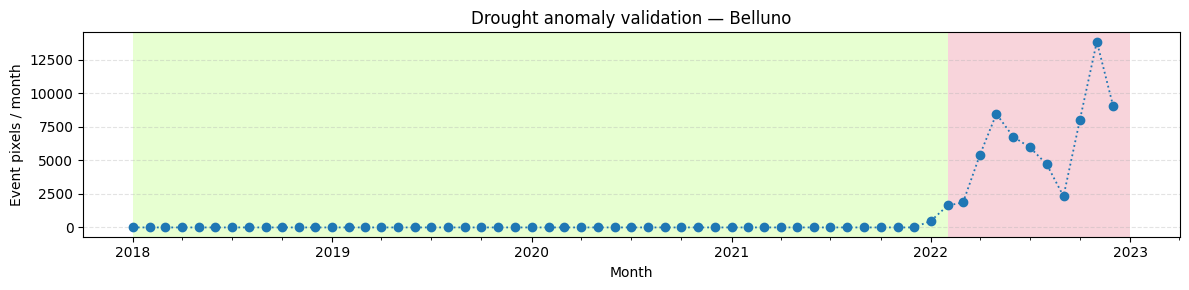

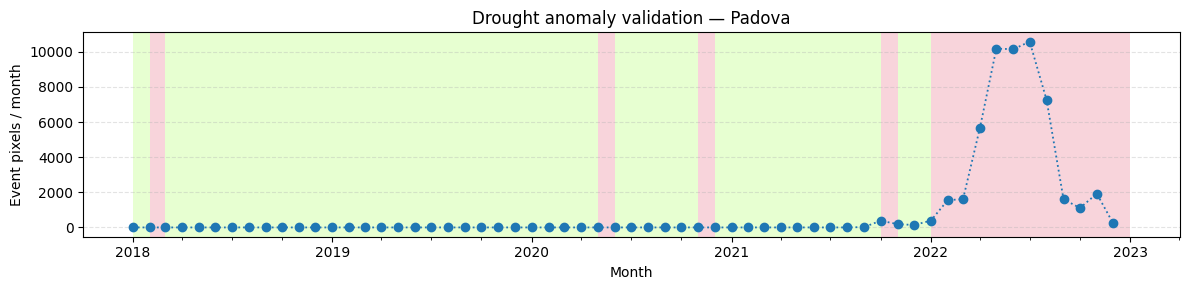

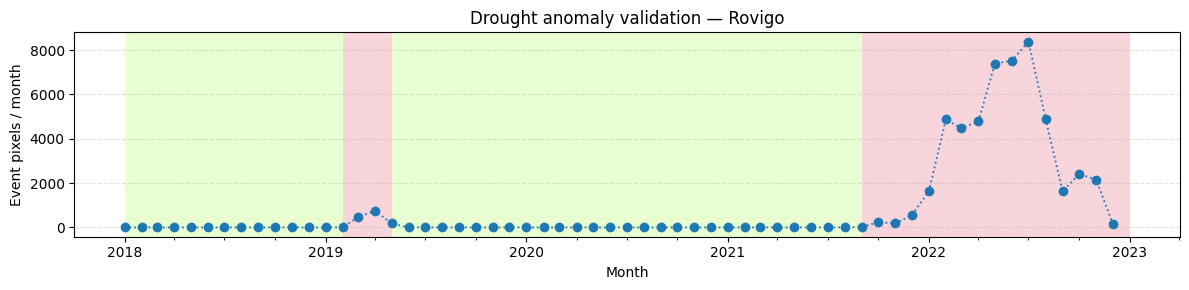

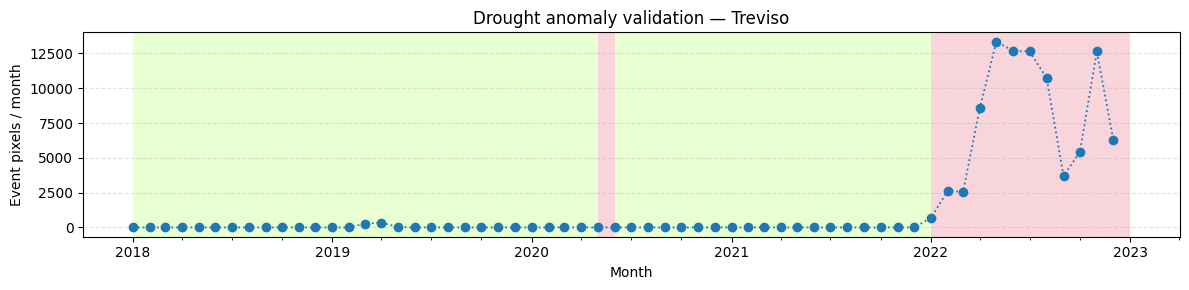

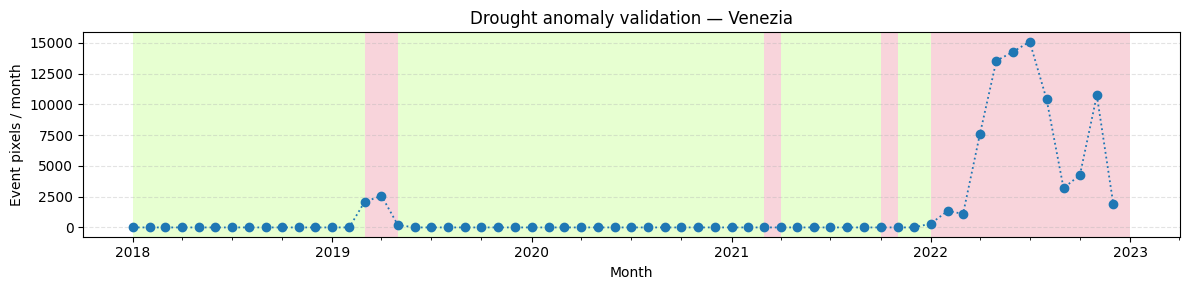

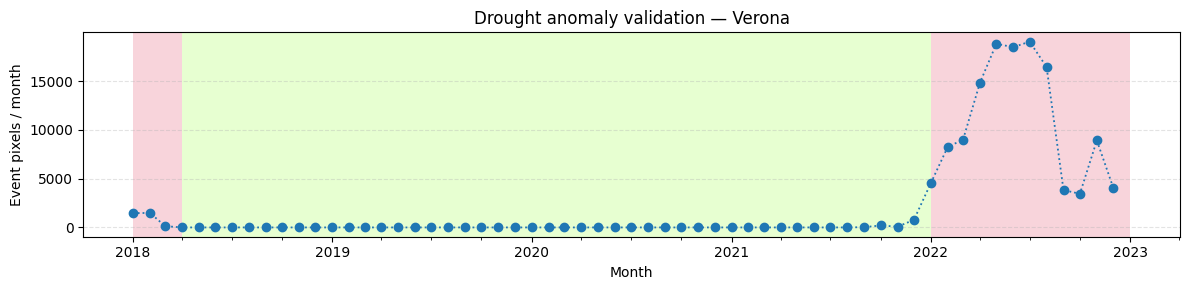

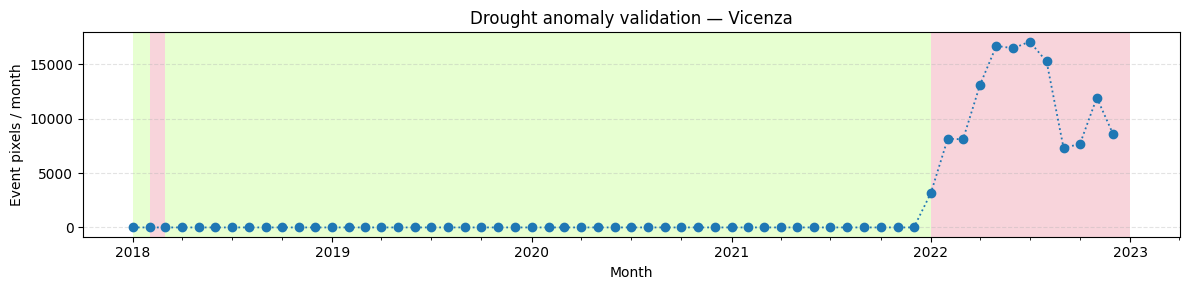

In [14]:
# 4) plots
plot_all_provinces(
    merged_df=merged,
    out_dir="OUTPUT/validation_plots_drought",
    title_prefix="Drought anomaly validation"
)

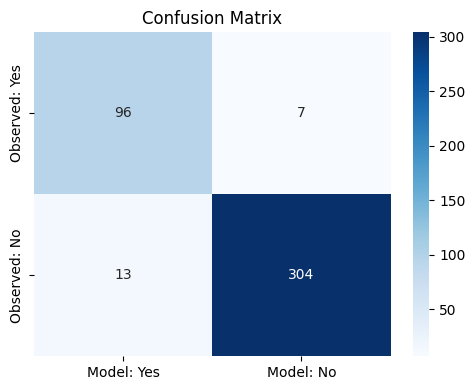

In [17]:
plot_confusion_matrix(metrics, normalize=False)

In [18]:
excel_path = "heat_anomalies_veneto.xlsx"

clusters_csv = "OUTPUT/CMCC_REA/heat/94_YES_F_clust_clean_veneto_only.csv"   # <-- your file
province_shp = "Limiti/Regioni/c0104021_province.shp"                        # <-- your shapefile
province_name_col = "provincia"                                        # <-- change to your field

PROV_CODE_MAP = {
    "VR": "Verona",
    "VI": "Vicenza",
    "BL": "Belluno",
    "TV": "Treviso",
    "VE": "Venezia",
    "PD": "Padova",
    "RO": "Rovigo",
}

# 1) model monthly per province
monthly = aggregate_daily_events_to_province_month(
    clusters_csv=clusters_csv,
    province_shp=province_shp,
    province_name_col=province_name_col,
    event_col="T_2M_THRES",      # <-- your heat anomaly flag
    event_is_binary=True,
    year_range=(2018, 2022),
)

val = load_validation_matrix_month_provcodes(
    "heat_anomalies_veneto.xlsx",
    month_col="Month",
    province_code_map=PROV_CODE_MAP
)

# 3) compare
merged, metrics = compare_validation_to_clusters(
    monthly, val,
    presence_rule="any_pixel"
)

print(metrics)

I found a pixel!
This is the df     province      month  n_pixels_month  n_days_month  n_unique_pixels  model
0         BL 2018-01-01             453             4              151      1
1         BL 2018-04-01            3514             7              697      1
2         BL 2018-09-01             453             3              151      1
3         BL 2019-02-01            1926             8              534      1
4         BL 2019-03-01             173             3               58      1
..       ...        ...             ...           ...              ...    ...
154       VR 2022-01-01             300             3              155      1
155       VR 2022-05-01            1230             4              404      1
156       VR 2022-07-01            2610            11              593      1
157       VR 2022-10-01            4192            13              632      1
158       VR 2022-11-01             136             1              136      1

[159 rows x 6 columns]
This is 

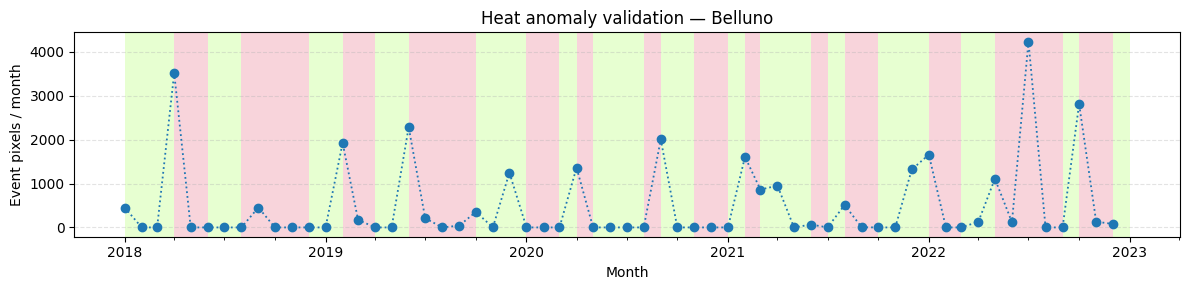

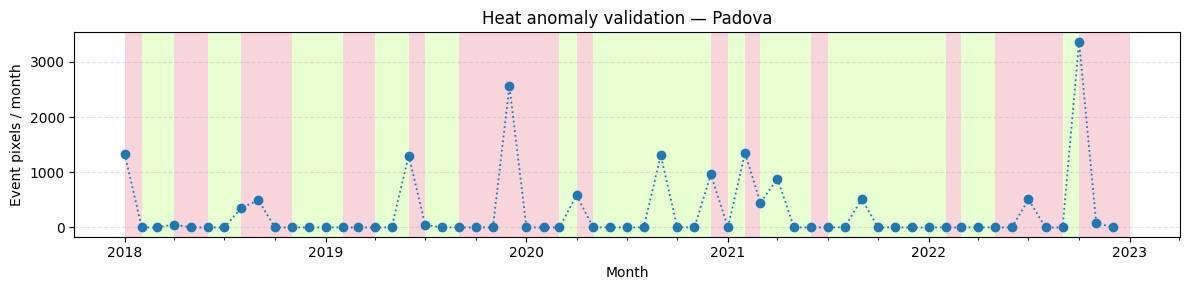

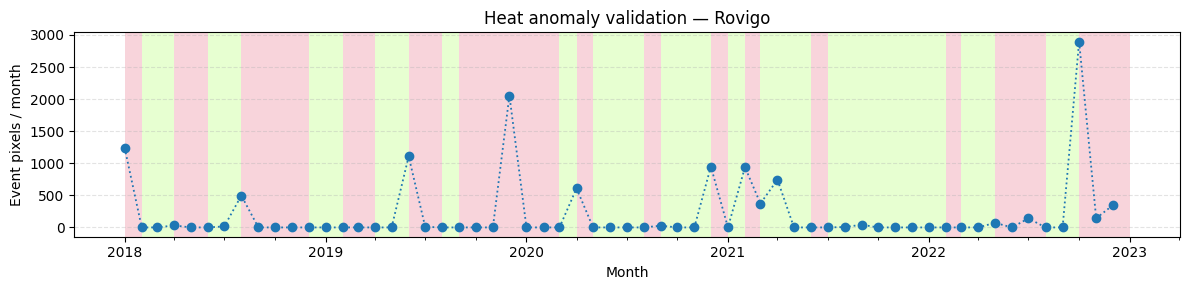

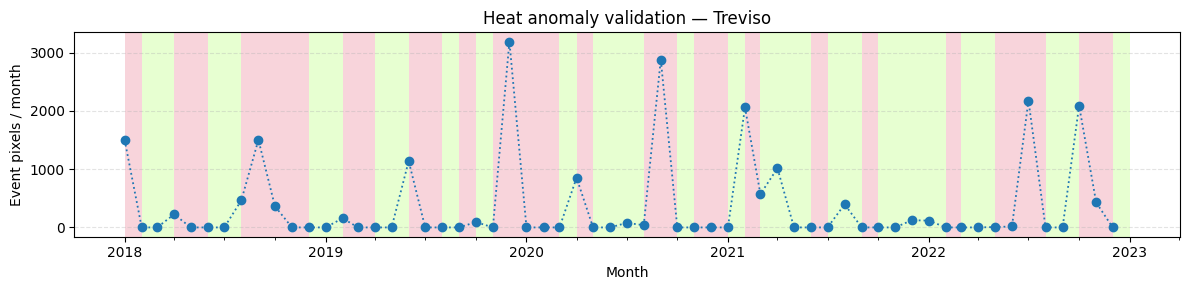

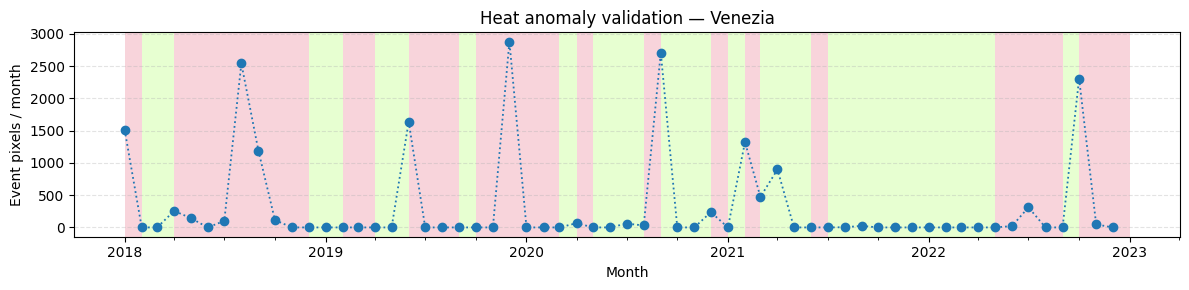

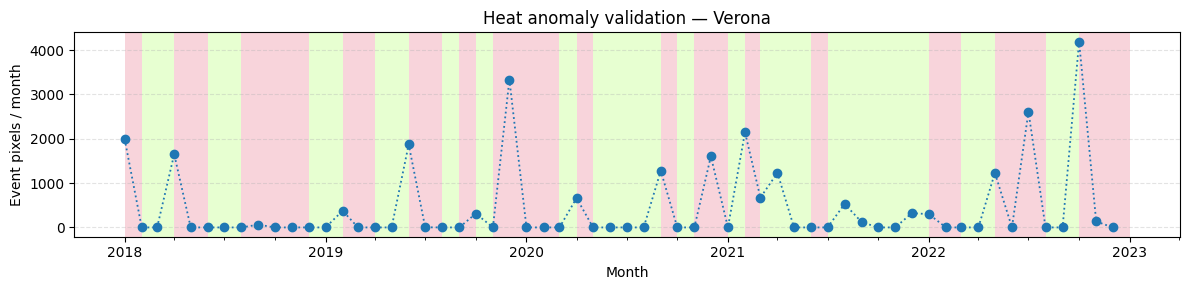

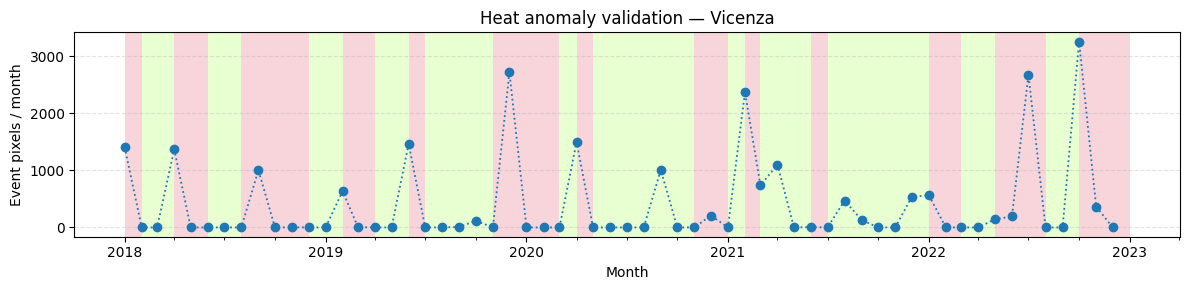

In [19]:
# 4) plots
plot_all_provinces(
    merged_df=merged,
    out_dir="OUTPUT/validation_plots_heat",
    title_prefix="Heat anomaly validation"
)

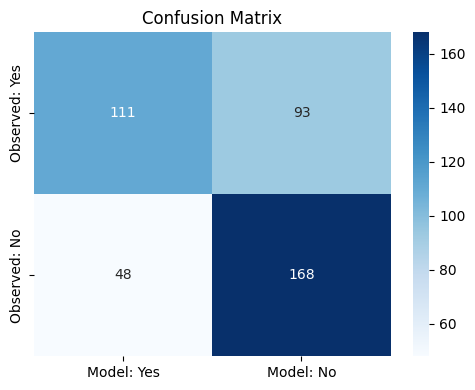

In [20]:
plot_confusion_matrix(metrics, normalize=False)